核心逻辑：按理论拆解模块，从底层实现关键组件，不依赖高阶封装

1. 模块 1：位置编码（解决 Transformer 无时序依赖的缺陷）
理论回顾：Transformer 通过正弦 / 余弦函数注入位置信息，公式为：
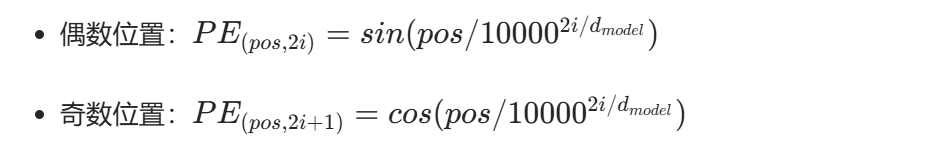

3. 模块 2：缩放点积注意力（Transformer 核心注意力机制）
理论回顾：
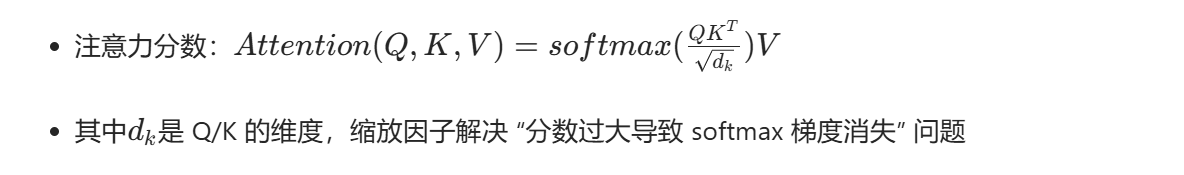

4. 模块 3：多头注意力（并行捕捉多维度特征）
理论回顾：
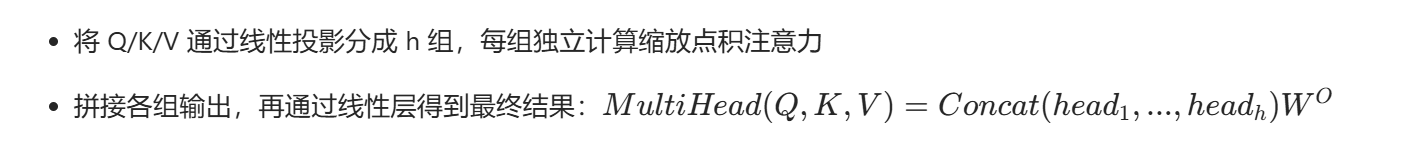

5. 模块 4：编码器层（Transformer 编码器基本单元）
理论回顾：每层 = 多头自注意力 + 前馈网络 + 残差连接 + LayerNorm
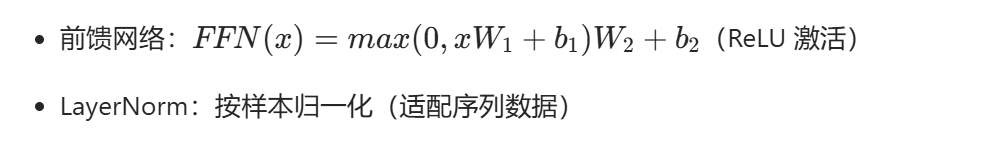

6. 模块 5：简化版 Transformer 整体架构（用于机器翻译）
理论回顾：编码器（6 层 EncoderLayer）+ 解码器（简化为 3 层，核心逻辑一致）+ 输出投影层


In [1]:
#位置编码

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

class PositionalEncoding(layers.Layer):
    def __init__(self, d_model, max_seq_len=512):
        super().__init__()
        self.d_model = d_model  # 模型维度（词嵌入+位置编码的总维度）
        self.max_seq_len = max_seq_len
        
        # 生成位置编码矩阵：(max_seq_len, d_model)
        pos_enc = self._compute_positional_encoding()
        self.pos_enc = tf.Variable(pos_enc, trainable=False)  # 位置编码不训练
    
    def _compute_positional_encoding(self):
        pos = tf.range(self.max_seq_len, dtype=tf.float32)[:, tf.newaxis]  # (max_seq_len, 1)
        i = tf.range(self.d_model, dtype=tf.float32)[tf.newaxis, :]  # (1, d_model)
        denominator = tf.pow(10000.0, 2 * (i // 2) / self.d_model)  # 分母：10000^(2i/d_model)
        
        pos_enc = tf.where(
            tf.math.mod(i, 2) == 0,  # 偶数维度用sin
            tf.sin(pos / denominator),
            tf.cos(pos / denominator)  # 奇数维度用cos
        )
        return pos_enc  # (max_seq_len, d_model)
    
    def call(self, x):
        # x: (batch_size, seq_len, d_model) - 词嵌入输出
        seq_len = tf.shape(x)[1]
        # 只取前seq_len个位置的编码，与词嵌入相加
        return x + self.pos_enc[:seq_len, :]

2026-03-16 18:48:36.219386: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-16 18:48:36.219465: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-16 18:48:36.220532: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
#缩放点积注意力

class ScaledDotProductAttention(layers.Layer):
    def __init__(self):
        super().__init__()
    
    def call(self, Q, K, V, mask=None):
        # Q: (batch_size, num_heads, seq_len_q, d_k)
        # K: (batch_size, num_heads, seq_len_k, d_k)
        # V: (batch_size, num_heads, seq_len_v, d_v)（seq_len_k=seq_len_v）
        d_k = tf.shape(Q)[-1]
        
        # 1. 计算QK^T / sqrt(d_k)：(batch_size, num_heads, seq_len_q, seq_len_k)
        scores = tf.matmul(Q, K, transpose_b=True)  # QK^T
        scaled_scores = scores / tf.math.sqrt(tf.cast(d_k, tf.float32))
        
        # 2. 应用掩码（如解码器的掩码多头注意力，屏蔽未来位置）
        if mask is not None:
            scaled_scores = tf.where(mask == 0, -1e9, scaled_scores)  # 掩码位置设为极小值，softmax后接近0
        
        # 3. softmax归一化 + 与V相乘
        attn_weights = tf.nn.softmax(scaled_scores, axis=-1)  # (batch_size, num_heads, seq_len_q, seq_len_k)
        output = tf.matmul(attn_weights, V)  # (batch_size, num_heads, seq_len_q, d_v)
        
        return output, attn_weights  # 返回注意力输出和权重（用于可视化）


In [3]:
#多头注意力

#多头注意力
class MultiHeadAttention(layers.Layer):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.d_model = d_model  # 模型总维度
        self.num_heads = num_heads  # 头数
        self.d_k = d_model // num_heads  # 每个头的维度（必须整除）
        
        # 线性投影层（Q、K、V各一个，输出层一个）
        self.w_q = layers.Dense(d_model)
        self.w_k = layers.Dense(d_model)
        self.w_v = layers.Dense(d_model)
        self.w_o = layers.Dense(d_model)
    
    def split_heads(self, x, batch_size):
        # x: (batch_size, seq_len, d_model) → 拆分多头：(batch_size, num_heads, seq_len, d_k)
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.d_k))
        return tf.transpose(x, perm=[0, 2, 1, 3])  # 调整维度顺序
    
    def call(self, q, k, v, mask=None):
        batch_size = tf.shape(q)[0]
        
        # 1. 线性投影：(batch_size, seq_len, d_model)
        q_proj = self.w_q(q)
        k_proj = self.w_k(k)
        v_proj = self.w_v(v)
        
        # 2. 拆分多头：(batch_size, num_heads, seq_len, d_k)
        q_split = self.split_heads(q_proj, batch_size)
        k_split = self.split_heads(k_proj, batch_size)
        v_split = self.split_heads(v_proj, batch_size)
        
        # 3. 计算缩放点积注意力
        attn_output, attn_weights = ScaledDotProductAttention()(q_split, k_split, v_split, mask)
        
        # 4. 拼接多头输出：(batch_size, seq_len, d_model)
        attn_output = tf.transpose(attn_output, perm=[0, 2, 1, 3])  # (batch_size, seq_len, num_heads, d_k)
        concat_output = tf.reshape(attn_output, (batch_size, -1, self.d_model))  # 拼接
        
        # 5. 最终线性投影
        output = self.w_o(concat_output)
        return output, attn_weights
    
    # 关键修复：实现compute_mask方法，消除掩码警告
    def compute_mask(self, inputs, mask=None):
        # 传递输入的mask（或返回None，告诉Keras该层不处理mask）
        return mask[0] if mask is not None else None

In [4]:
#编码器层（Transformer 编码器基本单元）：每层 = 多头自注意力 + 前馈网络 + 残差连接 + LayerNorm

class EncoderLayer(layers.Layer):
    def __init__(self, d_model, num_heads, d_ff, dropout_rate=0.1):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_ff = d_ff  # 前馈网络隐藏层维度
        
        # 核心组件
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = keras.Sequential([
            layers.Dense(d_ff, activation='relu'),
            layers.Dense(d_model)
        ])
        
        # 归一化和dropout
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)
    
    def call(self, x, training, mask=None):
        # x: (batch_size, seq_len, d_model)
        # 1. 多头自注意力 + 残差连接 + 归一化
        attn_output, _ = self.mha(x, x, x, mask)  # 自注意力：Q=K=V=x
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)  # Pre-Norm结构（先归一化再计算）
        
        # 2. 前馈网络 + 残差连接 + 归一化
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)
        
        return out2

    def compute_mask(self, inputs, mask=None):
        # 直接传递掩码，解决警告
        return mask

In [5]:
# 解码器层实现（补充完整）
class DecoderLayer(layers.Layer):
    def __init__(self, d_model, num_heads, d_ff, dropout_rate=0.1):
        super().__init__()
        self.mha1 = MultiHeadAttention(d_model, num_heads)  # 掩码多头自注意力
        self.mha2 = MultiHeadAttention(d_model, num_heads)  # 编码器-解码器注意力
        self.ffn = keras.Sequential([layers.Dense(d_ff, activation='relu'), layers.Dense(d_model)])
        
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm3 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)
        self.dropout3 = layers.Dropout(dropout_rate)
    
    # 修复：* 强制后续参数为关键字参数
    def call(self, x, enc_output, *, training, look_ahead_mask, padding_mask):
        # 1. 掩码多头自注意力（用前瞻掩码，正确）
        attn1, _ = self.mha1(x, x, x, look_ahead_mask)
        attn1 = self.dropout1(attn1, training=training)
        out1 = self.layernorm1(x + attn1)
        
        # 2. 编码器-解码器注意力（用【编码器填充掩码】）
        attn2, _ = self.mha2(out1, enc_output, enc_output, padding_mask)
        attn2 = self.dropout2(attn2, training=training)
        out2 = self.layernorm2(out1 + attn2)
        
        # 3. 前馈网络
        ffn_output = self.ffn(out2)
        ffn_output = self.dropout3(ffn_output, training=training)
        out3 = self.layernorm3(out2 + ffn_output)
        
        return out3
    
    # 可选：实现compute_mask，消除掩码警告
    def compute_mask(self, inputs, mask=None):
        return mask[0] if mask is not None else None

In [6]:
#简化版 Transformer 整体架构（用于机器翻译）

#简化版 Transformer 整体架构（用于机器翻译）
class Transformer(keras.Model):
    def __init__(self, num_layers, d_model, num_heads, d_ff, input_vocab_size, 
                 target_vocab_size, max_seq_len=512, dropout_rate=0.1):
        super().__init__()
        self.d_model = d_model
        self.num_layers = num_layers
        
        # 编码器部分
        self.encoder_embedding = layers.Embedding(input_vocab_size, d_model)  # 输入词嵌入
        self.pos_encoding = PositionalEncoding(d_model, max_seq_len)
        self.encoder_layers = [EncoderLayer(d_model, num_heads, d_ff, dropout_rate) 
                              for _ in range(num_layers)]
        self.dropout = layers.Dropout(dropout_rate)
        
        # 解码器部分（简化版，保留核心逻辑）
        self.decoder_embedding = layers.Embedding(target_vocab_size, d_model)  # 目标词嵌入
        self.decoder_layers = [DecoderLayer(d_model, num_heads, d_ff, dropout_rate) 
                              for _ in range(num_layers//2)]  # 简化为3层
        
        # 输出层：投影到目标词汇表
        self.final_layer = layers.Dense(target_vocab_size)
        
        # 标记是否已构建（可选，辅助Keras识别）
        self.built = False

    def build(self, input_shape):
        """
        显式实现build方法，声明输入形状并完成层构建
        input_shape: [(batch_size, enc_seq_len), (batch_size, dec_seq_len)]
        """
        # 1. 提取编码器/解码器输入形状
        enc_input_shape, dec_input_shape = input_shape
        
        # 2. 强制构建所有子层（触发子层的build逻辑）
        # 构建编码器嵌入层
        self.encoder_embedding.build(enc_input_shape)
        # 构建位置编码层（无参数，仅确认形状）
        self.pos_encoding.build((None, enc_input_shape[1], self.d_model))
        # 构建编码器层
        for layer in self.encoder_layers:
            layer.build((None, enc_input_shape[1], self.d_model))
        # 构建解码器嵌入层
        self.decoder_embedding.build(dec_input_shape)
        # 构建解码器层
        for layer in self.decoder_layers:
            # 解码器层输入：(dec_input, enc_output)
            layer.build([(None, dec_input_shape[1], self.d_model), 
                         (None, enc_input_shape[1], self.d_model)])
        # 构建输出层
        self.final_layer.build((None, dec_input_shape[1], self.d_model))
        
        # 3. 标记为已构建
        self.built = True

    def encode(self, x, training, mask):
        # 编码过程：词嵌入 + 位置编码 + 多层编码器
        seq_len = tf.shape(x)[1]
        x = self.encoder_embedding(x)  # (batch_size, seq_len, d_model)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))  # 缩放词嵌入（稳定训练）
        x = self.pos_encoding(x)
        x = self.dropout(x, training=training)
        
        for layer in self.encoder_layers:
            x = layer(x, training=training, mask=mask)
        return x  # (batch_size, seq_len, d_model)
    
    def decode(self, x, enc_output, training, look_ahead_mask, padding_mask):
        # 解码过程：词嵌入 + 位置编码 + 多层解码器
        seq_len = tf.shape(x)[1]
        x = self.decoder_embedding(x)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x = self.pos_encoding(x)
        x = self.dropout(x, training=training)
        
        for layer in self.decoder_layers:
            # 关键修改：将training、look_ahead_mask、padding_mask改为关键字参数传递
            x = layer(
                x, 
                enc_output, 
                training=training, 
                look_ahead_mask=look_ahead_mask, 
                padding_mask=padding_mask
            )
        return x  # (batch_size, seq_len, d_model)
    
    def call(self, inputs, training):
        # inputs: (enc_input, dec_input) → 编码器输入、解码器输入
        enc_input, dec_input = inputs
        
        # 生成掩码（简化实现，详细掩码逻辑见附录）
        enc_mask = self._create_padding_mask(enc_input)
        look_ahead_mask = self._create_look_ahead_mask(tf.shape(dec_input)[1])
        dec_mask = tf.maximum(self._create_padding_mask(dec_input), look_ahead_mask)
        
        # 编码 + 解码
        enc_output = self.encode(enc_input, training, enc_mask)
        dec_output = self.decode(dec_input, enc_output, training, look_ahead_mask, enc_mask)
        
        # 输出投影
        final_output = self.final_layer(dec_output)  # (batch_size, seq_len, target_vocab_size)
        return final_output
    
    # 辅助函数：生成padding掩码（屏蔽填充位）
    def _create_padding_mask(self, seq):
        seq = tf.cast(tf.math.equal(seq, 0), tf.float32)
        return seq[:, tf.newaxis, tf.newaxis, :]  # (batch_size, 1, 1, seq_len)
    
    # 辅助函数：生成look-ahead掩码（解码器屏蔽未来位置）
    def _create_look_ahead_mask(self, seq_len):
        mask = 1 - tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
        return mask  # (seq_len, seq_len)



In [7]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ===================== 【1】数据集路径（你的文件结构） =====================
DATA_FOLDER = "./de-en"
DE_FILE = "europarl-v7.de-en.de"
EN_FILE = "europarl-v7.de-en.en"

# ===================== 【2】超参数 =====================
MAX_VOCAB_SIZE = 30000
MAX_SEQ_LEN = 32
BATCH_SIZE = 128
VAL_SPLIT = 0.1  # 10% 数据做验证集

# ===================== 【3】读取本地数据（完全离线） =====================
def read_corpus(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = [line.strip() for line in f]
    return lines

de_path = os.path.join(DATA_FOLDER, DE_FILE)
en_path = os.path.join(DATA_FOLDER, EN_FILE)

de_sentences = read_corpus(de_path)
en_sentences = read_corpus(en_path)

assert len(de_sentences) == len(en_sentences), "德英句子数量不匹配"
print(f"✅ 读取完成：{len(de_sentences)} 对德英平行句")

# ===================== 【4】分词器（反转：英语输入，德语输出） =====================
# 英语分词器（INPUT：输入语言）
en_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~', oov_token="<OOV>")
en_tokenizer.fit_on_texts(en_sentences)

# 德语分词器（TARGET：输出语言）
de_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~', oov_token="<OOV>")
de_tokenizer.fit_on_texts(de_sentences)

# 转换序列
en_sequences = en_tokenizer.texts_to_sequences(en_sentences)
de_sequences = de_tokenizer.texts_to_sequences(de_sentences)

# 填充
en_input = pad_sequences(en_sequences, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
de_output = pad_sequences(de_sequences, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')

# ===================== 【5】构建 TF 数据集 =====================
def shift_labels(input_ids, labels):
    dec_input = labels[:, :-1]
    dec_target = labels[:, 1:]
    return (input_ids, dec_input), dec_target

# 构建完整数据集
dataset = tf.data.Dataset.from_tensor_slices((en_input, de_output))
dataset = dataset.shuffle(20000, seed=42).batch(BATCH_SIZE).map(shift_labels)

# 计算总样本数 & 验证集大小
total_samples = len(en_input)
val_size = int(total_samples * VAL_SPLIT)
train_size = total_samples - val_size

# ✅【关键】拆分训练集 和 验证集（两个独立数据集，彻底解决卡死）
train_dataset = dataset.take(train_size // BATCH_SIZE)
val_dataset = dataset.skip(train_size // BATCH_SIZE)

# ===================== 【6】验证输出 =====================
print("\n📊 数据集形状：")
for (enc_in, dec_in), dec_tar in dataset.take(1):
    print(f"编码器输入（英语）：{enc_in.shape}")
    print(f"解码器输入（德语）：{dec_in.shape}")
    print(f"解码器目标（徳语）：{dec_tar.shape}")

print("\n✅ 完全离线预处理完成！可直接训练")

✅ 读取完成：1920209 对德英平行句

📊 数据集形状：
编码器输入（英语）：(128, 32)
解码器输入（德语）：(128, 31)
解码器目标（徳语）：(128, 31)

✅ 完全离线预处理完成！可直接训练


In [8]:
import tensorflow as tf

# 1. 填充掩码：屏蔽序列中的0（padding）
def create_padding_mask(seq):
    seq = tf.cast(tf.math.equal(seq, 0), tf.float32)
    # 调整形状适配多头注意力：(batch_size, 1, 1, seq_len)
    return seq[:, tf.newaxis, tf.newaxis, :]

# 2. 前瞻掩码：解码器专用，屏蔽未来的token（核心修复！）
def create_look_ahead_mask(size):
    # 生成上三角矩阵，屏蔽未来位置
    mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)
    # 形状：(seq_len, seq_len)
    return mask

In [9]:
# ===================== 【7】模型初始化（适配本地分词器和数据集） =====================

import numpy as np
# 提取词汇表大小（+1是因为Tokenizer从1开始索引，0为填充位）
en_vocab_size = min(MAX_VOCAB_SIZE, len(en_tokenizer.word_index) + 1)
de_vocab_size = min(MAX_VOCAB_SIZE, len(de_tokenizer.word_index) + 1)

# Transformer超参数（适配小序列长度+大数据集，兼顾训练效率和效果）
NUM_LAYERS = 6        # 编码器层数（论文原版6层）
D_MODEL = 128         # 模型维度（缩小版，原版512，适配32长度序列）
NUM_HEADS = 4         # 多头注意力头数（D_MODEL必须能被NUM_HEADS整除）
D_FF = 512            # 前馈网络隐藏层维度（原版2048）
DROPOUT_RATE = 0.1    # Dropout率，防止过拟合

# 初始化Transformer模型（德译英）
model = Transformer(
    num_layers=NUM_LAYERS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    input_vocab_size=en_vocab_size,    # ✅ 输入：英语
    target_vocab_size=de_vocab_size,   # ✅ 输出：德语
    max_seq_len=MAX_SEQ_LEN,
    dropout_rate=DROPOUT_RATE
)

# ===================== 【8】定义损失函数和优化器（翻译任务专用） =====================
# 损失函数：稀疏交叉熵（标签为整数ID，无需one-hot），屏蔽填充位0
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction="none")

def compute_loss(labels, logits):
    mask = tf.math.logical_not(tf.math.equal(labels, 0))
    mask = tf.cast(mask, dtype=logits.dtype)
    loss = loss_fn(labels, logits) * mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

# 评估指标：准确率（屏蔽填充位）
def masked_accuracy(labels, logits):
    mask = tf.math.logical_not(tf.math.equal(labels, 0))
    pred = tf.argmax(logits, axis=-1)
    correct = tf.equal(pred, tf.cast(labels, tf.int64))
    correct = tf.logical_and(correct, mask)
    return tf.reduce_sum(tf.cast(correct, tf.float32)) / tf.reduce_sum(tf.cast(mask, tf.float32))

# 优化器：Adam（严格遵循Transformer论文推荐参数）
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-4,
    beta_1=0.9,
    beta_2=0.98,
    epsilon=1e-9
)

# ===================== 【9】模型编译 =====================
model.compile(
    optimizer=optimizer,
    loss=compute_loss,
    metrics=[masked_accuracy]
)

# 打印模型概况（可选，查看各层参数）
print("\n📌 Transformer模型概况：")
model.build(input_shape=[(None, MAX_SEQ_LEN), (None, MAX_SEQ_LEN-1)])
model.summary()

# ===================== 【10】模型训练 =====================
# 训练参数（可根据你的GPU性能调整）
EPOCHS = 2            # 训练轮数，300M数据集建议至少5轮

# 开始训练
print("\n🚀 开始训练：英语 → 德语 翻译模型")
history = model.fit(
    train_dataset,            # ✅ 独立训练集
    epochs=EPOCHS,
    validation_data=val_dataset,  # ✅ 独立验证集
    verbose=1
)


📌 Transformer模型概况：
Model: "transformer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       multiple                  3840000   
                                                                 
 positional_encoding (Posit  multiple                  4096      
 ionalEncoding)                                                  
                                                                 


ValueError: Weights for model 'sequential' have not yet been created. Weights are created when the model is first called on inputs or `build()` is called with an `input_shape`.

In [ ]:
# ===================== 【11】训练结果可视化（可选，查看损失/准确率变化） =====================
import matplotlib.pyplot as plt
# 设置中文字体（避免乱码）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 绘制损失曲线
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='训练损失')
plt.plot(history.history['val_loss'], label='验证损失')
plt.title('损失曲线')
plt.xlabel('轮数')
plt.ylabel('损失')
plt.legend()

# 绘制准确率曲线
plt.subplot(1, 2, 2)
plt.plot(history.history['masked_accuracy'], label='训练准确率')
plt.plot(history.history['val_masked_accuracy'], label='验证准确率')
plt.title('准确率曲线')
plt.xlabel('轮数')
plt.ylabel('准确率')
plt.legend()

plt.tight_layout()
plt.savefig('transformer_train_result.png')  # 保存图片到本地
plt.show()

# ===================== 【12】模型保存（可选，保存训练好的模型用于后续预测） =====================
model.save_weights('./transformer_de2en_weights.h5')  # 保存权重（轻量）
model.save('./transformer_de2en_model')              # 保存完整模型（含结构）
print("\n✅ 模型训练完成！权重已保存至：./transformer_de2en_weights.h5")